Trade PnL summary:
count    545.000000
mean       5.370753
std       84.958088
min     -829.488895
25%       -6.674313
50%        4.296842
75%       18.157058
max      509.909259
Name: pnl, dtype: float64
Total trades: 545
Wins: 340 (62.4%), Losses: 197 (37.6%)
Average win: 35.34, Average loss: -46.13
Max win: 509.91, Max loss: -829.49


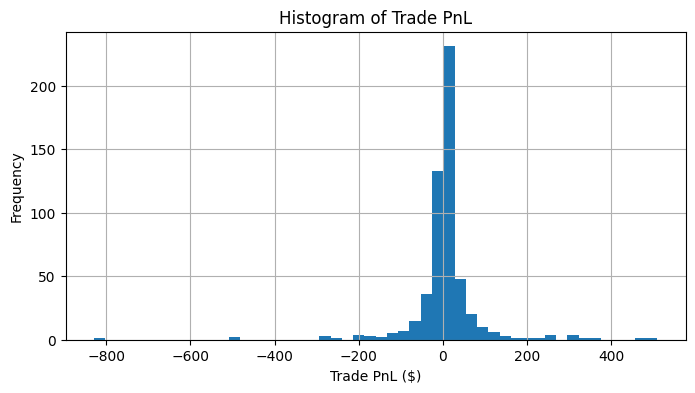

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load trades
trades_df = pd.read_csv('all_trades.csv')

# Basic stats
print("Trade PnL summary:")
print(trades_df['pnl'].describe())

# Win/loss stats
n_trades = len(trades_df)
n_wins = (trades_df['pnl'] > 0).sum()
n_losses = (trades_df['pnl'] < 0).sum()
win_rate = n_wins / n_trades
avg_win = trades_df.loc[trades_df['pnl'] > 0, 'pnl'].mean()
avg_loss = trades_df.loc[trades_df['pnl'] < 0, 'pnl'].mean()
max_win = trades_df['pnl'].max()
max_loss = trades_df['pnl'].min()

print(f"Total trades: {n_trades}")
print(f"Wins: {n_wins} ({win_rate:.1%}), Losses: {n_losses} ({1-win_rate:.1%})")
print(f"Average win: {avg_win:.2f}, Average loss: {avg_loss:.2f}")
print(f"Max win: {max_win:.2f}, Max loss: {max_loss:.2f}")

# Plot histogram again for reference
plt.figure(figsize=(8,4))
trades_df['pnl'].hist(bins=50)
plt.title('Histogram of Trade PnL')
plt.xlabel('Trade PnL ($)')
plt.ylabel('Frequency')
plt.show()

   entry_date   exit_date  entry_price  exit_price direction         pnl  \
0  2023-04-13  2023-04-18   137.752390  129.618691     short   28.467948   
1  2023-04-26  2023-07-06   140.446739  102.098158     short  268.440068   
2  2023-03-30  2023-04-17   102.467913  111.687492     short   64.537052   
3  2023-04-19  2023-05-30   118.417289  112.893550     short   19.333088   
4  2023-05-25  2023-06-05    92.383028   95.675181     short   11.522534   

   holding_period  
0               3  
1              48  
2              11  
3              28  
4               6  
       entry_price  exit_price         pnl  holding_period
count   137.000000  137.000000  137.000000      137.000000
mean    170.829172  167.802786   -5.474500       19.072993
std     202.743117  202.896817   92.084303       15.571767
min     -90.207021 -120.214773 -283.969186        0.000000
25%      19.905884   23.346403  -47.508092        6.000000
50%     121.117163  117.470654    5.273679       16.000000
75%     22

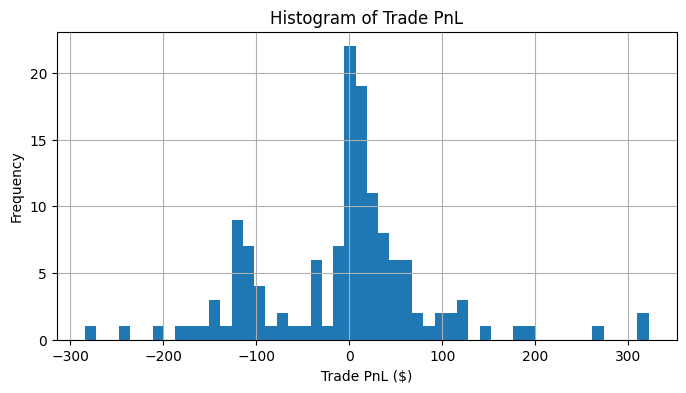

In [2]:
import pandas as pd

# Load all trades
trades_df = pd.read_csv('all_trades.csv')

# Show the first few trades
print(trades_df.head())

# Show summary statistics
print(trades_df.describe())

# Show the worst losses
print(trades_df.nsmallest(10, 'pnl'))

# Show the largest wins
print(trades_df.nlargest(10, 'pnl'))

# Check for any trades with loss greater than your stop loss
stop_loss = 100  # or whatever your config is
print(trades_df[trades_df['pnl'] < -stop_loss])

# Plot histogram of trade PnL
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
trades_df['pnl'].hist(bins=50)
plt.title('Histogram of Trade PnL')
plt.xlabel('Trade PnL ($)')
plt.ylabel('Frequency')
plt.show()

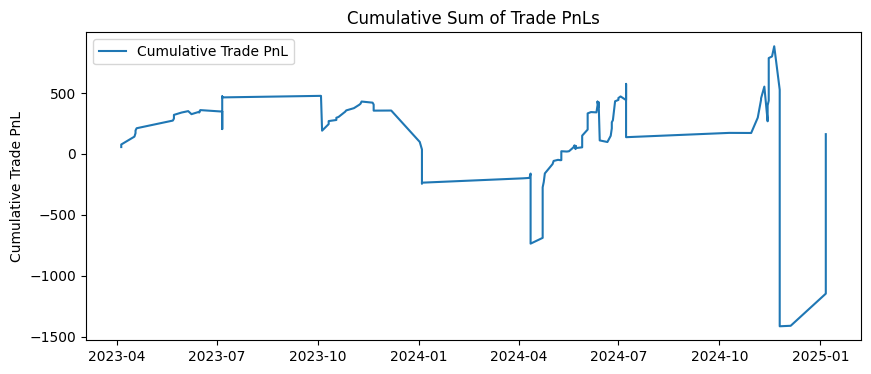

NameError: name 'cumulative_returns' is not defined

<Figure size 1000x400 with 0 Axes>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load all trades (if not already loaded)
trades_df = pd.read_csv('all_trades.csv')

# Ensure trades are sorted by exit date
trades_df['exit_date'] = pd.to_datetime(trades_df['exit_date'])
trades_df = trades_df.sort_values('exit_date')

# Compute rolling (cumulative) sum of trade PnLs
trades_df['cumulative_trade_pnl'] = trades_df['pnl'].cumsum()

# Plot cumulative trade PnL
plt.figure(figsize=(10, 4))
plt.plot(trades_df['exit_date'], trades_df['cumulative_trade_pnl'], label='Cumulative Trade PnL')
plt.ylabel('Cumulative Trade PnL')
plt.title('Cumulative Sum of Trade PnLs')
plt.legend()
plt.show()

# Compare to portfolio cumulative return (already computed in your script)
plt.figure(figsize=(10, 4))
plt.plot(cumulative_returns.index, cumulative_returns.values, label='Portfolio Cumulative Return')
plt.plot(trades_df['exit_date'], trades_df['cumulative_trade_pnl'] / initial_capital, label='Cumulative Trade PnL (normalized)')
plt.ylabel('Cumulative Return')
plt.title('Portfolio Cumulative Return vs. Cumulative Trade PnL')
plt.legend()
plt.show()